# Project 2: Reinforcement Learning

### Group number
### Student Name 1
### Student Name 2
### ...

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In Project 1, you were asked to implement two exact algorithms to solve the Frozen Lake. In this project, you will be asked to implement four different model-free algorithms to solve a similar problem with larger state space, and compare your results.

## 1. The Flags Domain

In the Flags domain, time is broken up into discrete decision periods, and the world is a
square area that is broken up into a 5-by-5 grid of cells, as illustrated in Figure 1 below.
At the beginning of each period, a robot occupies one of the available cells. It is then
allowed to choose a direction of movement (up, down, left or right), and moves to the
corresponding adjacent cell in that direction. However, if the chosen action would take
the robot outside the boundaries of the grid, the robot does not move but remains in
the current cell.

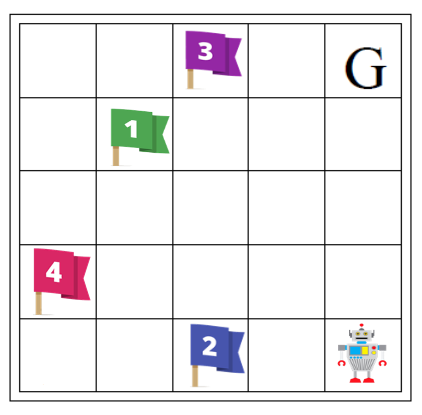



<h1><center>Figure 1: 5x5 Flags Domain</center></h1>

In each episode, the robot begins in the right lower corner. As illustrated in Figure 1, instead of a single
destination G, there are four different flags, numbered 1, 2, 3 and 4, that must be
collected in the correct order (first 1, then 2, etc... to 4). Once the robot has collected all the flags in the correct order and lands on cell G, the task is complete. If the robot collects the wrong flag at the wrong time (e.g. tries to collect 2 first, then 1...), the robot does not have to start over. Instead, the robot is penalized for taking this action, and the wrong flag is not collected (you may assume for training purposes, that the flags that have already been collected so far are kept). The main objective is to collect all the flags in the correct order in the least possible amount of time.

### 2. Problem modelling [15 Marks]

You are tasked with modelling the Flags environment. Then, you are asked to provide a programming description of the problem that will be used to solve it computationally using model-free reinforcement learning.

2.1.Answer the following questions:

(a) Define the state $(S)$ and action spaces $(A)$.[2 Marks]

State Space:

Pairs of: (Grid position (i,j), Flag most recently acquired (k))

Action Space:

{L, R, U, D}

(b) Construct a reward function ($R$) that aligns with the goal(s) you want your robot to achieve. [2 Marks]

R(s',a, s)

-Manhattan distance between robot location and flag k+1

-1000 for flags > k+1 

(c) Based on Figure 1, what is an optimal policy for this problem? You may explain your policy by drawing Figure 1 and trace the path the robot should take. Is there more than one optimal policy?[3 Marks]

2.2 Implement the dynamics of the Flags environment. [8 Marks]

In [7]:
# imports
import random
from matplotlib import pyplot as plt

In [56]:
class Flags:
    def __init__(self):
        self.init_state = (4, 4, 0)     # state tuple (x, y, recent_flag_captured). recent_flag_captured = 0 if none captured
        self.goal_state = (0, 4, 4)     
        self.goal_loc = (0, 4)
        self.flag_locs = {1: (1, 1), 2: (4, 2), 3: (0, 2), 4: (3, 0)}
        self.loc_flags = {(1, 1): 1, (4, 2): 2, (0, 2): 3, (3, 0): 4}
        self.map_action_to_movement = {'l': (0, -1), 'r': (0, 1), 'u': (-1, 0), 'd': (1, 0)}

    # return the initial state ...
    def reset(self):
        return self.init_state

    # return a list containing all the possible states in the environment
    def states_space(self):
        return [(x, y, flag) for x in range(5) for y in range(5) for flag in range(5)]
    
    # checks whether the provided grid location is within bounds
    def check_valid_loc(self, loc): 
        if not(0 <= loc[0] <= 4) or not(0 <= loc[1] <= 4):
            return False
        return True

    # return a list containing all the possible actions corresponding to the given state
    def actions_space(self, state):
        return ['l', 'r', 'u', 'd']
        # curr_x, curr_y = state[0], state[1]
        # valid_actions = []

        # for action, move in self.map_action_to_movement.items():
        #     new_x, new_y = curr_x + move[0], curr_y + move[1]
        #     if (0 <= new_x <= 4) and (0 <= new_y <= 4):
        #         valid_actions.append(action)

        # return valid_actions
    
    # dense reward
    def reward(self, state, next_state):
        new_loc, curr_flag, new_flag = next_state[:2], state[-1], next_state[-1]
        
        # check whether the state is already goal state
        if next_state == self.goal_state:
            return 0

        penalty = 0
        # if new location on grid is the wrong order flag or the goal state without having captured all 4 flags, penalize
        if (new_loc in self.loc_flags and self.loc_flags[new_loc] > curr_flag + 1) or (new_loc == self.goal_loc and new_flag < 4):
            penalty = -20
        
        if new_flag < 4:
            target = self.flag_locs[new_flag + 1]
        else:   # if all 4 flags captured already
            target = self.goal_loc

        # return negative manhattan distance to the next flag/goal
        return -1*(abs(target[0] - new_loc[0]) + abs(target[1] - new_loc[1])) + penalty
    
    # environment transition returns s' and r.
    def transition(self, state, action):

        # get new location with given state and action
        movement = self.map_action_to_movement[action]
        new_loc, curr_flag = (state[0] + movement[0], state[1] + movement[1]), state[-1]

        if not self.check_valid_loc(new_loc): # if new_loc is out of bounds, don't move
            new_loc = state[:2]

        # if collected all flags
        if curr_flag == 4:
            if new_loc == self.goal_loc:
                next_state = self.goal_state
            else:
                next_state = (new_loc[0], new_loc[1], curr_flag)
        else:
            # if the new grid location has a flag and it is the next flag, capture it
            if new_loc in self.loc_flags and self.flag_locs[curr_flag + 1] == new_loc:
                next_state = (new_loc[0], new_loc[1], curr_flag + 1)
            # if not the next flag, don't capture
            else:
                next_state = (new_loc[0], new_loc[1], curr_flag)
        
        return next_state, self.reward(state, next_state)

In [57]:
env = Flags()
test_states = [
    # given valid states
    (4, 4, 0), # work swell
    (1, 2, 0), # works well
    (4, 1, 1), # works well
    (2, 1, 1), # works well
    (0, 1, 1), # works well
    (4, 0, 2), # works well
    (0, 3, 3), # works well
    (0, 3, 4), # works well

    # given goal state
    (0, 4, 4),
]
for state in test_states:
    rewards = []
    for action in ['l', 'r', 'u', 'd']:
        next_state, reward = env.transition(state, action)
        rewards.append(reward)
    print(f"For {state} with 4 actions, reward is {rewards}.")
    print(f"For {state} with actions is {env.actions_space(state)}.")

For (4, 4, 0) with 4 actions, reward is [-5, -6, -5, -6].
For (4, 4, 0) with actions is ['l', 'r', 'u', 'd'].
For (1, 2, 0) with 4 actions, reward is [-4, -2, -22, -2].
For (1, 2, 0) with actions is ['l', 'r', 'u', 'd'].
For (4, 1, 1) with 4 actions, reward is [-2, -4, -2, -1].
For (4, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (2, 1, 1) with 4 actions, reward is [-4, -2, -4, -2].
For (2, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (0, 1, 1) with 4 actions, reward is [-6, -24, -5, -4].
For (0, 1, 1) with actions is ['l', 'r', 'u', 'd'].
For (4, 0, 2) with 4 actions, reward is [-6, -5, -25, -6].
For (4, 0, 2) with actions is ['l', 'r', 'u', 'd'].
For (0, 3, 3) with 4 actions, reward is [-5, -27, -6, -5].
For (0, 3, 3) with actions is ['l', 'r', 'u', 'd'].
For (0, 3, 4) with 4 actions, reward is [-2, 0, -1, -2].
For (0, 3, 4) with actions is ['l', 'r', 'u', 'd'].
For (0, 4, 4) with 4 actions, reward is [-1, 0, 0, -1].
For (0, 4, 4) with actions is ['l', 'r', 'u', 'd'].


### 3 Monte Carlo Method [35 Marks]

In this section, you are asked to implement Monte Carlo methods to solve the flags domain. Use a discount factor of
$\gamma= 0.99$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point, the episode ends.Training should proceed for a total of 2000 episodes.


3.1.Create a function $generate\_episode$ which takes as input a policy $\pi$ and the environment. This function should return the tuple of states, actions and rewards generated in an episode following $\pi$.    [5 Marks]

In [58]:
# 3.1 - Generate Episode

def generate_episode(init_state: tuple, init_action: str, policy: dict, env: Flags):
    env.reset()
    goal_state = env.goal_state
   
    curr_state, init_reward = env.transition(init_state, init_action)
    states, actions, rewards = [init_state], [init_action], [init_reward]
    t = 1   # since S_0, A_0, R_1 already initialized and appended to array

    while curr_state != goal_state and t < 200:
        action = random.choices(env.actions_space(curr_state), weights=policy[curr_state])[0]
        next_state, reward = env.transition(curr_state, action)
        states.append(curr_state)               # S_t
        actions.append(action)                  # A_t
        rewards.append(reward)                  # R_t+1
        curr_state = next_state
        t += 1
    
    return states, actions, rewards

3.2.Implement the first-visit Monte Carlo (for $\epsilon$-soft policies) control algorithm to find the approximate optimal
policy $\pi^*$. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and include plots in your report for each of these values. What is the best value of $\epsilon$? Why? For each $\epsilon$, did your algorithm converge at all? What was the final policy and
Q-values that you typically obtain (typically, as in the majority of the trials)? Does this correspond to an optimal policy? Visualize the learning process (for instance, change in Q for some state; or any other visualization) to support your claims.  [15 Marks]

In [59]:
# 3.2 - Plotting helper function

def create_plots(env, q, policy, epsilon):

    # plot the q values for each state
    fig1, axis1 = plt.subplots(1, 5, figsize=(50, 10))
    fig1.suptitle(f"Graph of Q values for each flag state-action pair for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis1[i].plot(range(2000), q[(state, action)], label=f"{action}")
        axis1[i].set_xlabel('Episode', fontsize=20)
        axis1[i].set_ylabel('Q', fontsize=20)
        axis1[i].set_xticks(range(0, 2000, 500), range(0, 2000, 500))
        axis1[i].set_title(f'State = {state}', fontsize=20)
        axis1[i].tick_params(axis='both', labelsize=20)
        axis1[i].legend(fontsize=20)

    # plot the policy values for each action for each state
    fig2, axis2 = plt.subplots(1, 5, figsize=(50, 10))
    fig2.suptitle(f"Graph of policy values for each action for each flag state for every episode (epsilon = {epsilon})", fontsize=20)

    for i, state in enumerate([(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]):
        for action in env.actions_space(state):
            axis2[i].plot(range(2000), policy[(state, action)], label=f"{action}")
        axis2[i].set_xlabel('Episode', fontsize=20)
        axis2[i].set_ylabel('Probability based on policy', fontsize=20)
        axis2[i].set_xticks(range(0, 2000, 500), range(0, 2000, 500))
        axis2[i].set_title(f'State = {state}', fontsize=20)
        axis2[i].tick_params(axis='both', labelsize=20)
        axis2[i].legend(fontsize=20)
   

In [60]:
# 3.2 - First Visit Monte Carlo

def first_visit_mc(epsilon: float, env: Flags):
    gamma = 0.99
    all_states = env.states_space()

    # initialize stochastic policy as equiprobable for all actions
    policy = {state: [1/len(env.actions_space(state))]*len(env.actions_space(state)) for state in all_states} # stochastic policy follows this format: {key=state: value=[prob of 'l', prob of 'r', prob of 'u', prob of 'd']}
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    returns = {(state, action): [] for state in all_states for action in env.actions_space(state)} 

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}
    
    for k in range(2000):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=policy[rand_state])[0]

        # generate episode for the chosen state and action
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, policy, env)
        pairs = [(state_ep[i], action_ep[i]) for i in range(len(state_ep))]
        g = 0
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            prev_pairs = set(pairs[:t])
            g = (gamma * g) + reward_ep[t]

            # if first visit
            if (curr_state, curr_action) not in prev_pairs:
                returns[(curr_state, curr_action)].append(g)
                q[(curr_state, curr_action)] = sum(returns[(curr_state, curr_action)]) / len(returns[(curr_state, curr_action)])

                # find argmax_a [Q(S,a)]
                best_q, a_star = 0, 'l'
                for action in env.actions_space(curr_state):
                    if q[(curr_state, action)] > best_q:
                        a_star = action
                        best_q = q[(curr_state, action)]
                
                for i, action in enumerate(env.actions_space(curr_state)):
                    # update policy by indexing actions (since action array is in order: ['l', 'r', 'u', 'd'])
                    policy[curr_state][i] = 1 - epsilon + (epsilon / len(env.actions_space(curr_state))) if action == a_star else epsilon / len(env.actions_space(curr_state))

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(env.actions_space(state)):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state][i]]
                else:
                    graph_policy[(state, action)].append(policy[state][i])

    create_plots(env, graph_q_values, graph_policy, epsilon)
            
    return policy, q


Epsilon = 0.01
Policy: {(0, 0, 0): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 0, 1): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 0, 2): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 0, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 0, 4): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 1, 0): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 1, 1): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 1, 2): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 1, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 1, 4): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 0): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 1): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 2): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 3): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 2, 4): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 3, 0): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 3, 1): [0.9924999999999999, 0.0025, 0.0025, 0.0025], (0, 3, 

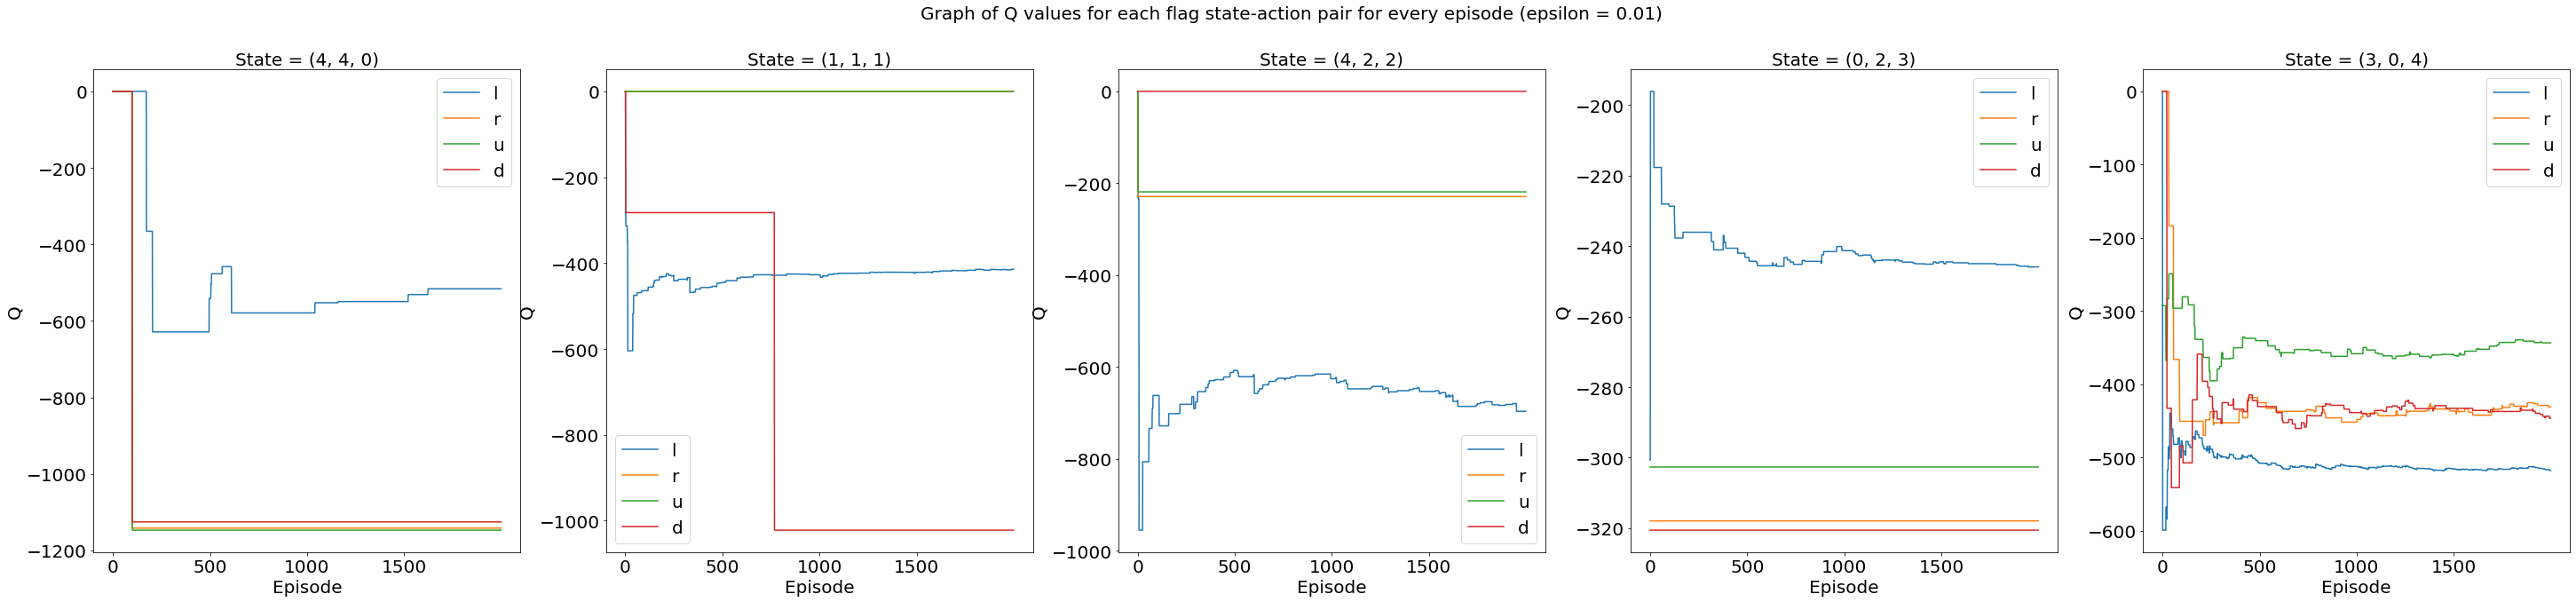

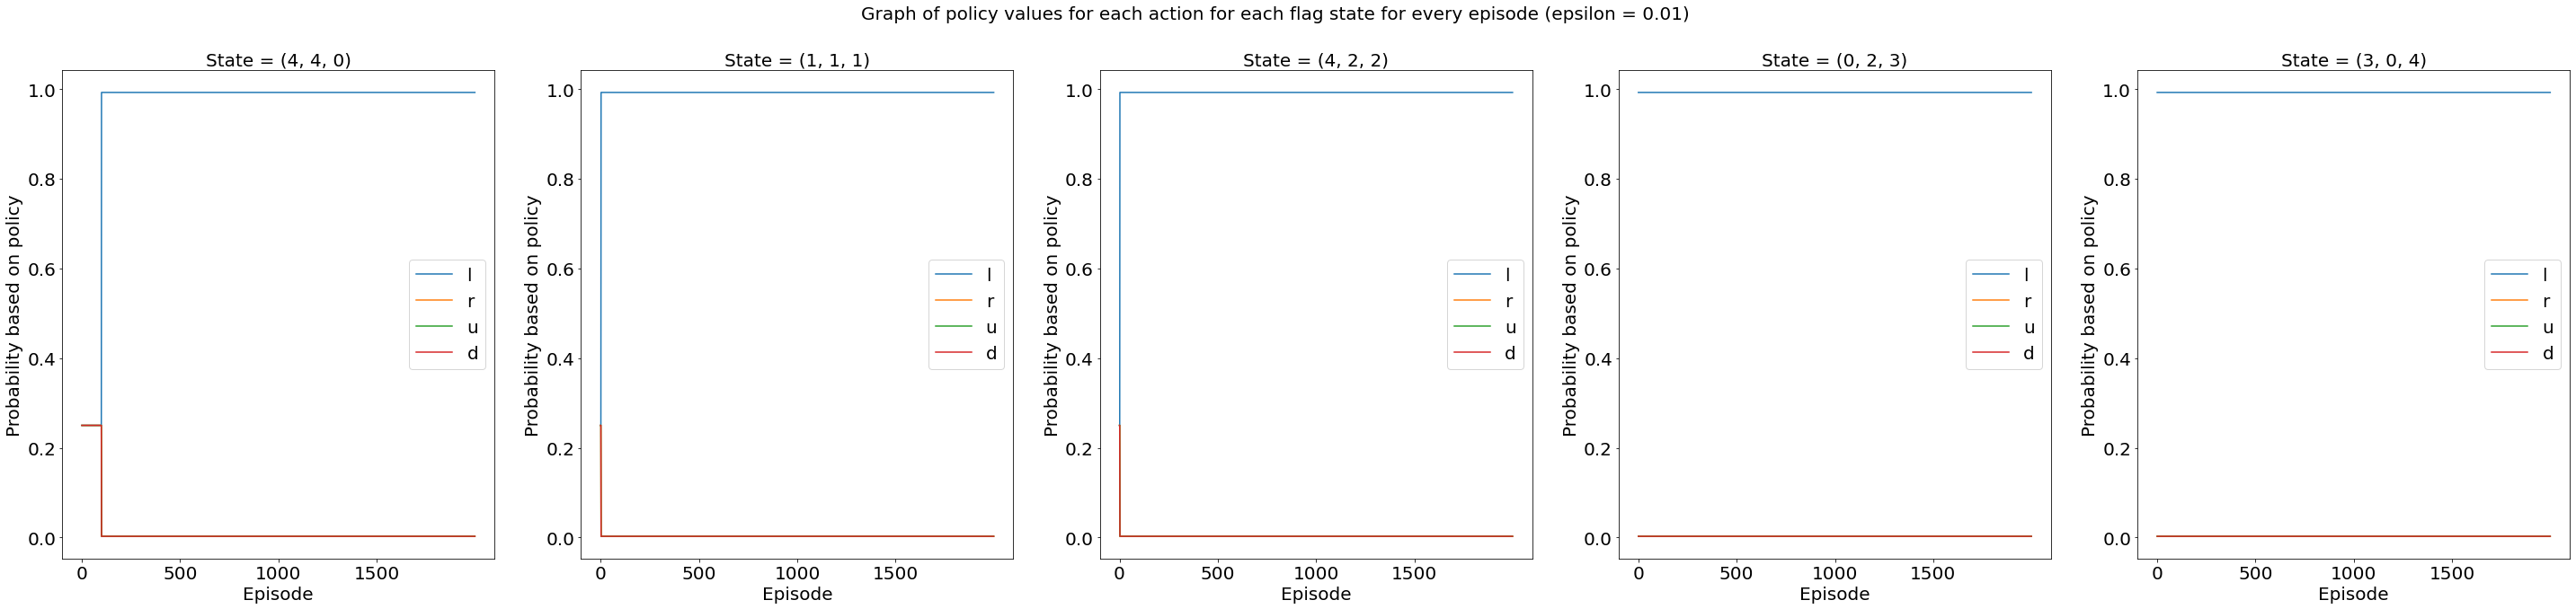

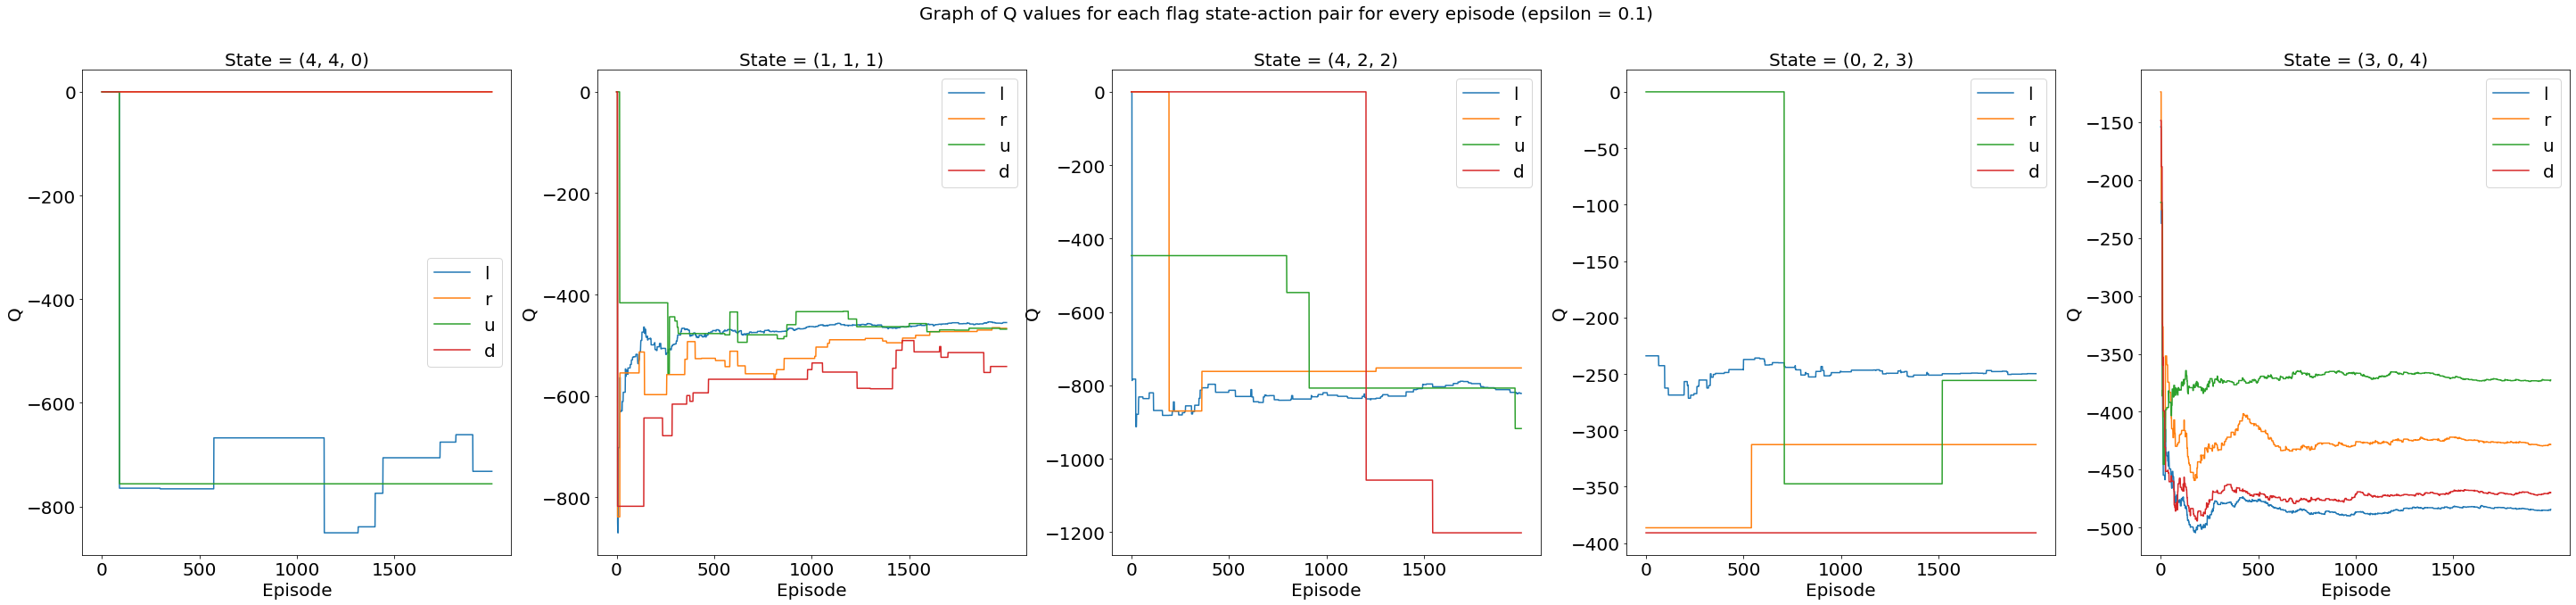

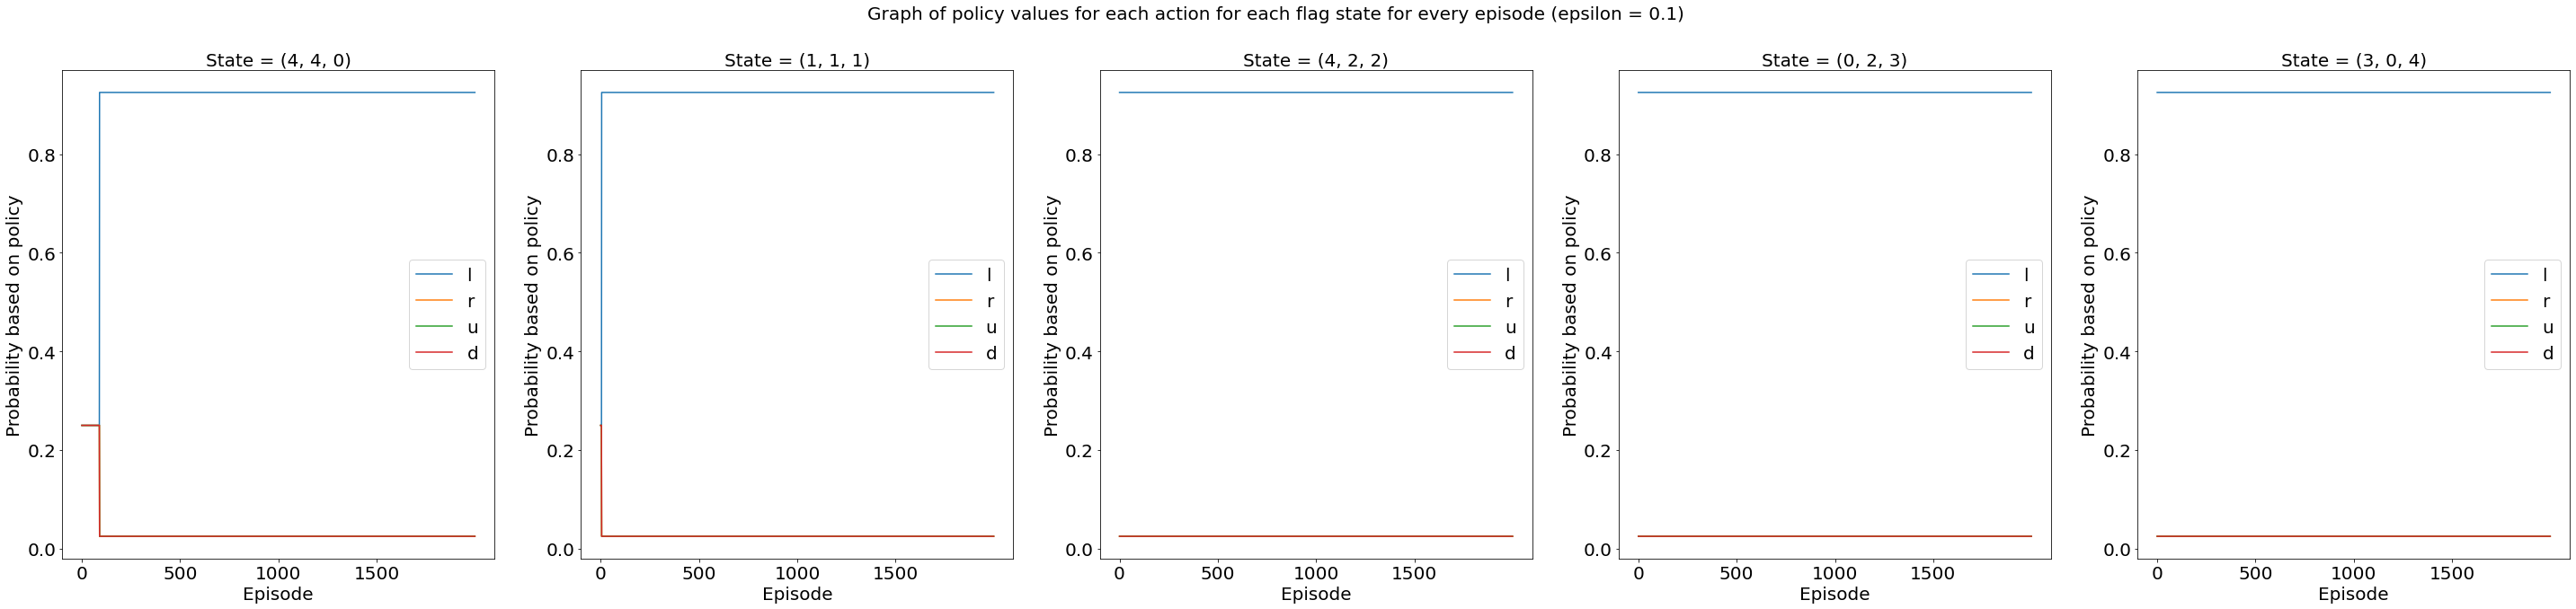

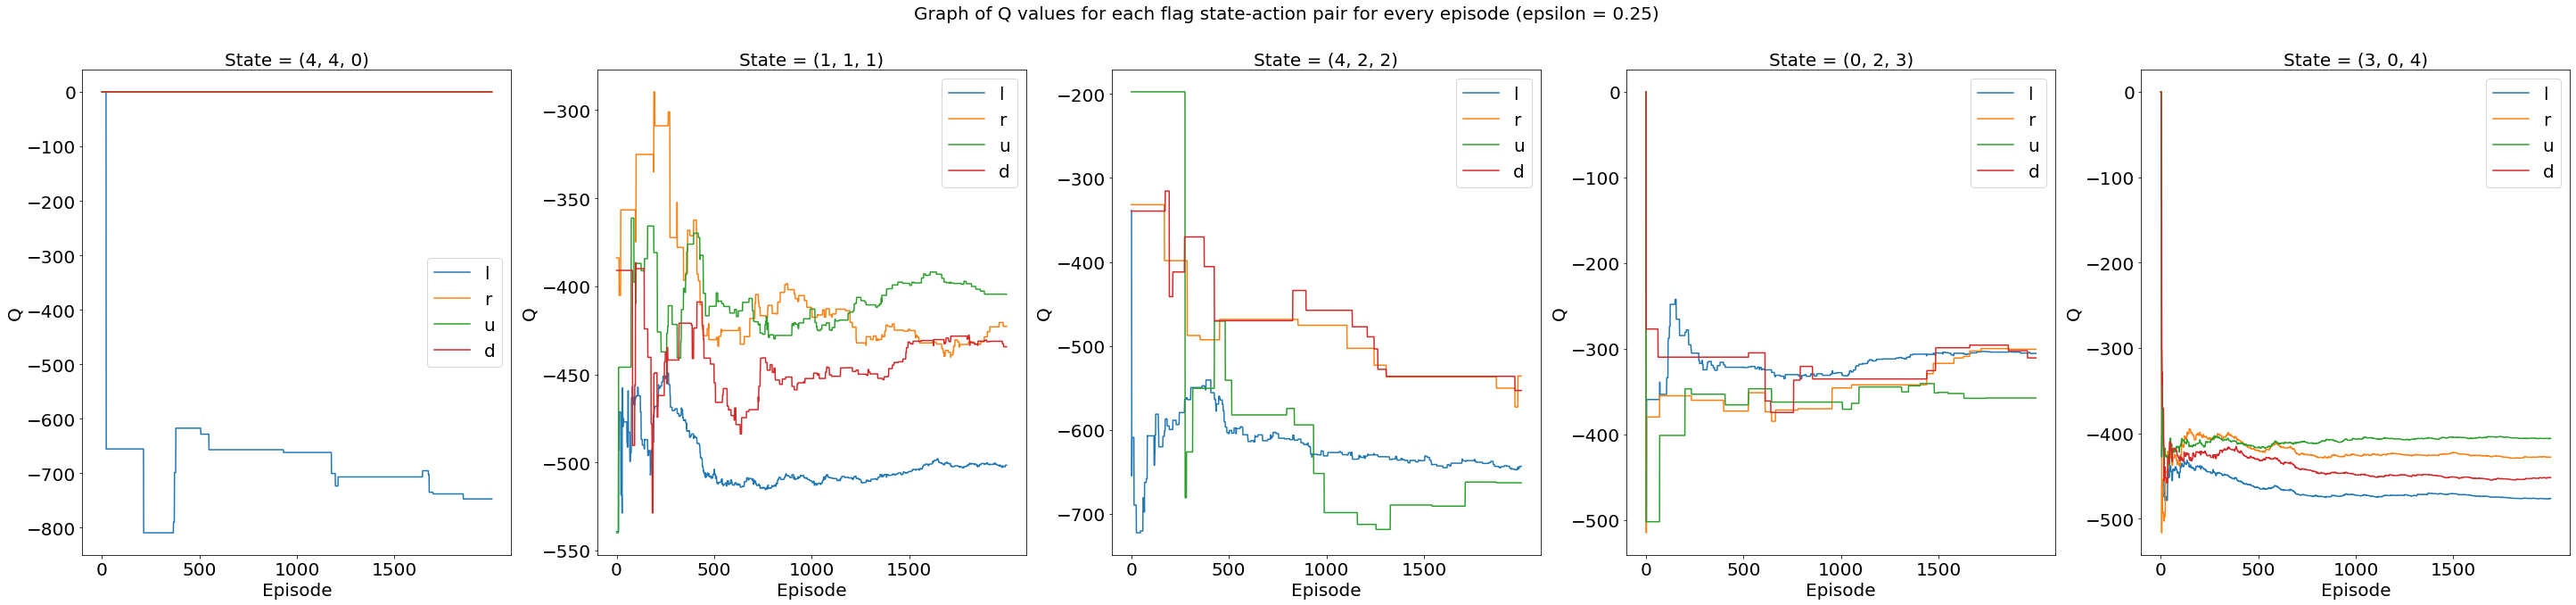

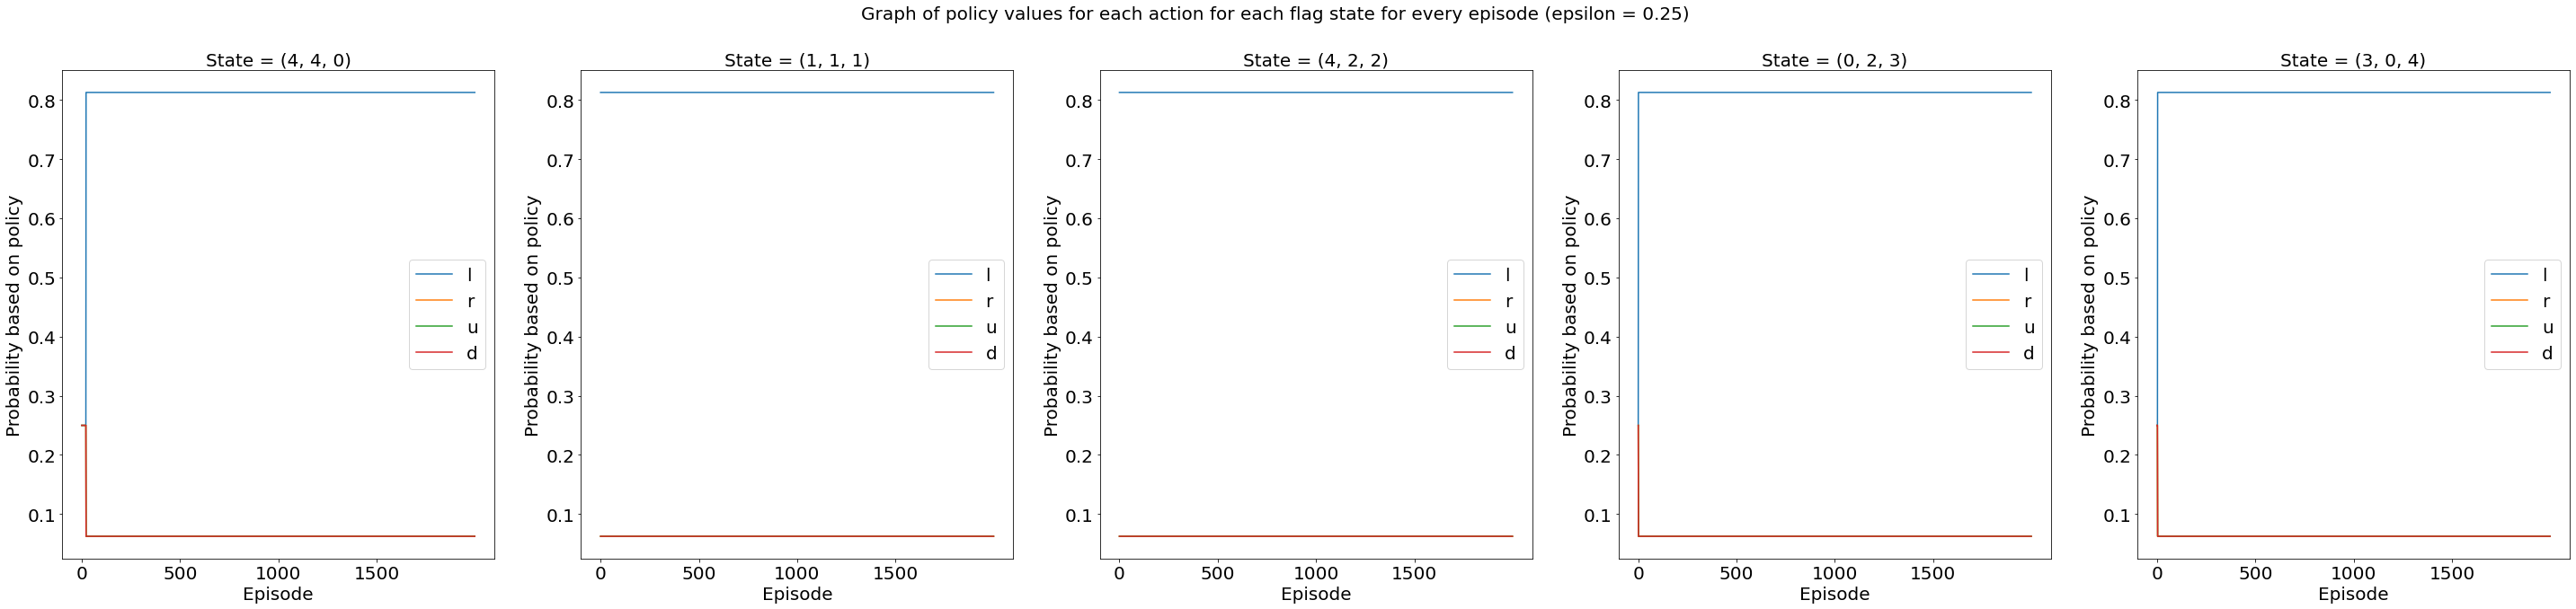

In [63]:
env = Flags()

for epsilon in (0.01, 0.1, 0.25):
    pi, q = first_visit_mc(epsilon, env)
    print(f"Epsilon = {epsilon}")
    print(f"Policy: {pi}")
    print(f"Q: {q}")


What is the best epsilon and why?
For each epsilon, did it converge at all? -> talk about the distribution of pi for each state
What was the pi/v for each state after 2000 episodes? (pretty print)
Describe if each correspond to an optimal policy

---Questions to address---

The plots for the Q values (state-action value function) and policy for 5 states are shown above. The 5 states are chosen such that they denote the initial state, and the state where a flag is captured.

Given that the epsilon value denotes the greediness of the polciy control, we can determine the "best" policy based on how deterministic a policy is. The graphs for the policies for each flag state display that the probabilities converged quite quickly. Based on the numerical values of the policies for each epsilon, it is evident that Epsilon = 0.01 has the nearest to deterministic policy as a single action has a probability very close to 1 and all other actions have probability 0.0025. This epsilon value achieves nearest to deterministic policy as compared to other epsilon values.

In terms of algorithm convergence, we can assess the convergence of Q values:

- For Epsilon = 0.01, after 1500 episodes, the state-action value function does not flunctuate too much and oscillates only slightly for all states that are graphed. This means that it is converging near the end of the 2000 episodes.
    
- For Epsilon = 0.1, it follows a similar pattern where after 1500 episodes, the state-action value functions are nearly constant. The only exception is for state (1, 1, 1) for actions 'u' and 'd', where there seems to be some flunctuations. However, this itself is not drastic.

- For Epsilon = 0.25, the state-value functions also remain quite constant after 1500 episodes. Some oscillation can be seen for state (4, 2, 2) for actions 'r' and 'd'; however, this is not a critical oscillation, and thus can be deemed as convergin.

Please see the print statements above the graph for the policy and state-value function (Q) evaluation after 2000 episodes.

Is this an optimal policy?

3.3.Consider a random behavior policy $b(a|s)=1/|A|$ for every state and action. Use episodes generated with $b$ to find the approximate optimal policy $\pi^*$. First use ordinary importance sampling Monte Carlo control. Then use weighted importance sampling Monte Carlo control. Answer the same questions as in 3.2.  [15 Marks]

In [169]:
# 3.3 - Off-policy Monte Carlo

def off_policy_mc(ratio_type: str, env: Flags):
    if ratio_type not in ["WIS", "OIS"]:
        raise ValueError("Invalid Importance Sampling Type. Please enter 'WIS' for weighted or 'OIS' for ordinary")
    
    gamma = 0.99
    all_states, all_actions = env.states_space(), ['l', 'r', 'u', 'd']

    # initialize
    policy = {state: 'l' for state in all_states} # deterministic policy since initialized as argmax
    q = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    c = {(state, action): 0 for state in all_states for action in env.actions_space(state)} 
    b = {state: [1/len(all_actions)]*len(all_actions) for state in all_states} # behaviour policy

    # storing values for plotting
    monitoring_states = [(4, 4, 0), (1, 1, 1), (4, 2, 2), (0, 2, 3), (3, 0, 4)]
    graph_q_values = {}
    graph_policy = {}

    for _ in range(2000):
        # choose a random state
        rand_state = random.choice(all_states)

        # choose a random action based on the behaviour policy of the random state
        rand_action = random.choices(env.actions_space(rand_state), weights=b[rand_state])[0]

        # generate episode using behaviour policy
        state_ep, action_ep, reward_ep = generate_episode(rand_state, rand_action, b, env)
        g = 0
        w = 1
        for t in range(len(state_ep)-1, -1, -1):
            curr_state, curr_action = state_ep[t], action_ep[t]
            g = (gamma * g) + reward_ep[t]
            c[(curr_state, curr_action)] = c[(curr_state, curr_action)] + w if ratio_type == "WIS" else c[(curr_state, curr_action)] + 1
            q[(curr_state, curr_action)] = q[(curr_state, curr_action)] + ((w / c[(curr_state, curr_action)]) * (g - q[(curr_state, curr_action)])) if ratio_type == "WIS" \
                else q[(curr_state, curr_action)] + ((1 / c[(curr_state, curr_action)]) * (w*g - q[(curr_state, curr_action)]))
            
            best_q, best_action = 0, policy[curr_state]
            for action in all_actions:
                if q[(curr_state, action)] > best_q:
                    best_q = q[(curr_state, action)]
                    best_action = action

            policy[curr_state] = best_action

            if curr_action != best_action:
                break

            action_index = all_actions.index(curr_action)
            w = w / (b[curr_state][action_index])

        # for graphing
        for state in monitoring_states:
            for i, action in enumerate(all_actions):
                if (state, action) not in graph_q_values:
                    graph_q_values[(state, action)] = [q[(state, action)]]
                else:
                    graph_q_values[(state, action)].append(q[(state, action)])
                
                if (state, action) not in graph_policy:
                    graph_policy[(state, action)] = [policy[state]]
                else:
                    graph_policy[(state, action)].append(policy[state])
    
    return policy, q


In [171]:
env = Flags()

for ratio_type in ("WIS", "OIS"):
    pi, q = off_policy_mc(ratio_type, env)
    print(f"Type = {ratio_type}")
    print(f"Policy: {pi}")
    print(f"Q: {q}")

Type = WIS
Policy: {(0, 0, 0): 'l', (0, 0, 1): 'l', (0, 0, 2): 'l', (0, 0, 3): 'l', (0, 0, 4): 'l', (0, 1, 0): 'l', (0, 1, 1): 'l', (0, 1, 2): 'l', (0, 1, 3): 'l', (0, 1, 4): 'l', (0, 2, 0): 'l', (0, 2, 1): 'l', (0, 2, 2): 'l', (0, 2, 3): 'l', (0, 2, 4): 'l', (0, 3, 0): 'l', (0, 3, 1): 'l', (0, 3, 2): 'l', (0, 3, 3): 'l', (0, 3, 4): 'l', (0, 4, 0): 'l', (0, 4, 1): 'l', (0, 4, 2): 'l', (0, 4, 3): 'l', (0, 4, 4): 'l', (1, 0, 0): 'l', (1, 0, 1): 'l', (1, 0, 2): 'l', (1, 0, 3): 'l', (1, 0, 4): 'l', (1, 1, 0): 'l', (1, 1, 1): 'l', (1, 1, 2): 'l', (1, 1, 3): 'l', (1, 1, 4): 'l', (1, 2, 0): 'l', (1, 2, 1): 'l', (1, 2, 2): 'l', (1, 2, 3): 'l', (1, 2, 4): 'l', (1, 3, 0): 'l', (1, 3, 1): 'l', (1, 3, 2): 'l', (1, 3, 3): 'l', (1, 3, 4): 'l', (1, 4, 0): 'l', (1, 4, 1): 'l', (1, 4, 2): 'l', (1, 4, 3): 'l', (1, 4, 4): 'l', (2, 0, 0): 'l', (2, 0, 1): 'l', (2, 0, 2): 'l', (2, 0, 3): 'l', (2, 0, 4): 'l', (2, 1, 0): 'l', (2, 1, 1): 'l', (2, 1, 2): 'l', (2, 1, 3): 'l', (2, 1, 4): 'l', (2, 2, 0): 'l', (2, 

### 4 Temporal Diference Control Methods [25 Marks]

In this section, you are asked to implement SARSA and Q-learning methods to solve the flags domain. Use a discount factor of $\gamma= 0.99$ and a learning rate of $\alpha = 0.3$ for all your experiments.Set the maximum length of each episode to 200 if the terminal state is not reached by this point.Training should proceed for a total of 500 episodes.

4.1. Implement the off-policy Q-learning algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2. [13 Marks]

4.2. Implement on-policy one-step Sarsa algorithm as discussed in class. Test  $\epsilon=\{0.01, 0.1, 0.25\}$ and  answer the same questions as in 3.2.[12 Marks]

### 5 Comparing Algorithms [25 Marks]

In the final section of your report, you must compare the different control algorithm you implemented on the Flags domain. In particular, please comment on at least the following issues in your report:

(a) Were the Q-value functions and policies you obtained using each algorithm similar? Were they different? Comment on this using the properties of each algorithm you learned in class [6 Marks]

(b) Use the plots you created for each ε to make a detailed comparison of the performance of the algorithms implemented in 3.2, 4.1 and 4.2. Answer the following questions for each ε you tested. Which one converged the fastest on average? Which one the slowest? Which one
had lower variance and which had higher variance? Why? [6 Marks]

(c) choose one particular ε for all three algorithms and one of the importance sampling Monte Carlo control, compare their testing performances of policies learned by all the algorithm (try to visualize this comparison). [13 Marks]